
# Import Libraries

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Load Dataset

In [5]:
path = r"C:\Users\DELL\Downloads\churn_dataset.xlsx"
df = pd.read_excel(path)  
df.head() 

,Age,Tenure,Sex,Churn
0,56,8,Male,No
1,46,63,Female,No
2,32,11,Female,No
3,60,8,Male,No
4,25,35,Male,No


Data Exploration Analysis [DEA]

In [6]:
df.shape 

(100, 4)

In [7]:
df.columns

Index(['Age', 'Tenure', 'Sex', 'Churn'], dtype='object')

In [ ]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Age     100 non-null    int64 
 1   Tenure  100 non-null    int64 
 2   Sex     100 non-null    object
 3   Churn   100 non-null    object
dtypes: int64(2), object(2)
memory usage: 3.3+ KB


Check Missing Values

In [9]:
df.isnull().sum() 

Age       0
Tenure    0
Sex       0
Churn     0
dtype: int64

Summary Statistics

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100.0,40.88,13.99082,18.0,30.50,41.0,53.25,64.0
Tenure,100.0,35.03,21.65732,1.0,14.75,35.0,54.25,71.0


In [11]:
#  Check Unique Values   
df.nunique() 

Age       43
Tenure    54
Sex        2
Churn      2
dtype: int64

In [12]:
df.dtypes    # To know categorical / Numerical coulmns 

Age        int64
Tenure     int64
Sex       object
Churn     object
dtype: object

In [13]:
df.select_dtypes(include='number').columns

Index(['Age', 'Tenure'], dtype='object')

In [ ]:
df.select_dtypes(include='object').columns 

Index(['Sex', 'Churn'], dtype='object')

Data Preprocessing

In [15]:
df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})


In [16]:
df

,Age,Tenure,Sex,Churn
0,56,8,1,0
1,46,63,0,0
2,32,11,0,0
3,60,8,1,0
4,25,35,1,0
...,...,...,...,...
95,24,38,0,0
96,26,24,1,0
97,41,69,0,1
98,18,70,1,0


In [19]:
df['Age'].value_counts() 

Age
61    6
41    5
32    4
42    4
64    4
38    4
31    4
19    4
56    3
35    3
24    3
26    3
57    3
53    3
21    3
43    3
25    3
62    3
46    3
59    2
33    2
45    2
18    2
39    2
20    2
28    2
40    2
29    1
34    1
58    1
60    1
48    1
27    1
51    1
23    1
37    1
52    1
50    1
36    1
47    1
54    1
55    1
44    1
Name: count, dtype: int64

In [20]:
df['Sex'].value_counts() 

Sex
0    54
1    46
Name: count, dtype: int64

Data Visualization 

<Axes: xlabel='Sex', ylabel='count'>

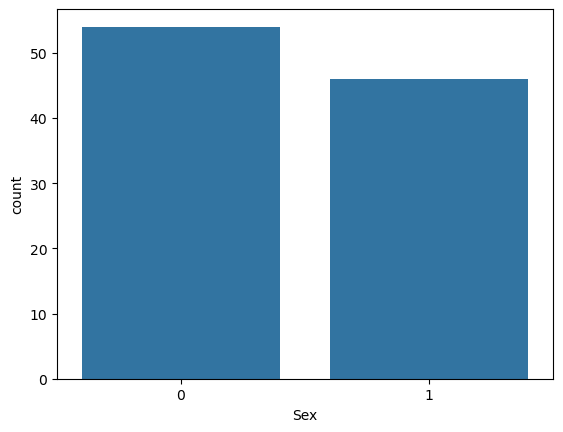

In [22]:
sns.countplot(x= df.Sex) 

<Axes: xlabel='Age', ylabel='Count'>

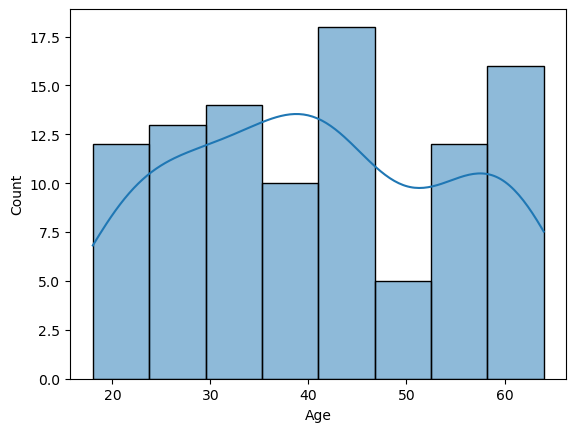

In [23]:
sns.histplot(df.Age, kde=True) 

Features and Target

In [24]:
X = df[['Age', 'Tenure', 'Sex']]
y = df['Churn']


In [25]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
#  Train Model
model = GaussianNB()
model.fit(X_train, y_train)


,priors,None
,var_smoothing,1e-09


In [27]:
# Predictions
y_pred = model.predict(X_test)


In [28]:
#  Evaluate Model
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)


Model Accuracy: 0.8


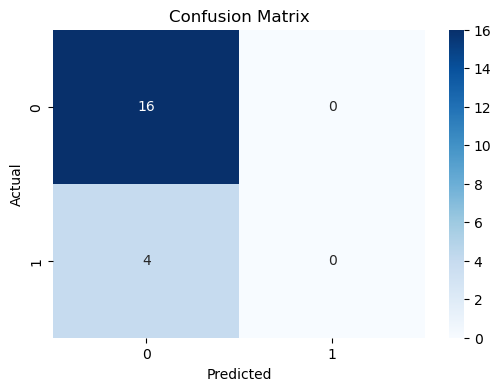

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Example prediction

In [30]:

new_customer = [[35, 12, 1]]  # Age, Tenure, Sex

prediction = model.predict(new_customer)
probability = model.predict_proba(new_customer)

print("Prediction:", "Churn" if prediction[0] == 1 else "No Churn")
print("Probability:", probability)

Prediction: No Churn
Probability: [[0.80631907 0.19368093]]


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
